In [1]:
!pip install pyrealsense2

   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.8 MB 187.9 kB/s eta 0:00:42
   ---------------------------------------- 0.0/7.8 MB 219.4 kB/s eta 0:00:36
    --------------------------------------- 0.1/7.8 MB 469.7 kB/s eta 0:00:17
    --------------------------------------- 0.2/7.8 MB 579.6 kB/s eta 0:00:14
   - -------------------------------------- 0.3/7.8 MB 1.1 MB/s eta 0:00:08
   -- ------------------------------------- 0.4/7.8 MB 1.3 MB/s eta 0:00:06
   -- ------------------------------------- 0.6/7.8 MB 1.3 MB/s eta 0:00:06
   --- ------------------------------------ 0.7/7.8 MB 1.5 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/7.8 MB 1.6 MB/s eta 0:00:05
   ---- ------------------------


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pyrealsense2 as rs

# Create a pipeline
pipeline = rs.pipeline()

# Create a config and configure the pipeline to stream
config = rs.config()
config.enable_stream(rs.stream.depth, 640, 480, rs.format.z16, 30)
config.enable_stream(rs.stream.color, 640, 480, rs.format.bgr8, 30)

# Start streaming
profile = pipeline.start(config)

try:
    # Wait for a coherent pair of frames: depth and color
    frames = pipeline.wait_for_frames()
    depth_frame = frames.get_depth_frame()
    color_frame = frames.get_color_frame()
    if not depth_frame or not color_frame:
        raise RuntimeError("Could not acquire depth or color frames.")

    # Example: get depth value at the center of the image
    width = depth_frame.get_width()
    height = depth_frame.get_height()
    center_depth = depth_frame.get_distance(int(width/2), int(height/2))
    print(f"Depth at center: {center_depth:.2f} meters")

    # Show all available cameras
    context = rs.context()
    devices = context.query_devices()
    print("Available cameras:")
    for i, device in enumerate(devices):
        print(f"Camera {i+1}: {device.get_info(rs.camera_info.name)}")

finally:
    # Stop streaming
    pipeline.stop()


Depth at center: 0.51 meters
Available cameras:
Camera 1: Intel RealSense D455


In [5]:
import pyrealsense2 as rs
import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time


In [6]:
def list_cameras():
    ctx = rs.context()
    devices = ctx.query_devices()
    print(f"Found {len(devices)} RealSense device(s):")
    for i, dev in enumerate(devices):
        name = dev.get_info(rs.camera_info.name)
        serial = dev.get_info(rs.camera_info.serial_number)
        print(f"  Device {i}: {name} (Serial: {serial})")
    return devices

devices = list_cameras()


Found 1 RealSense device(s):
  Device 0: Intel RealSense D455 (Serial: 152522251968)


In [7]:
pipeline = rs.pipeline()
config = rs.config()

# Configure streams
config.enable_stream(rs.stream.depth, 640, 480, rs.format.z16, 30)
config.enable_stream(rs.stream.color, 640, 480, rs.format.bgr8, 30)

print("Pipeline configured successfully")


Pipeline configured successfully


In [8]:
profile = pipeline.start(config)
print("Streaming started")

# Get stream info
depth_stream = profile.get_stream(rs.stream.depth)
color_stream = profile.get_stream(rs.stream.color)
print(f"Depth stream: {depth_stream}")
print(f"Color stream: {color_stream}")


Streaming started
Depth stream: <pyrealsense2.[video_]stream_profile: Depth(0) 640x480 @ 30fps Z16>
Color stream: <pyrealsense2.[video_]stream_profile: Color(0) 640x480 @ 30fps BGR8>


In [9]:
frames = pipeline.wait_for_frames()
depth_frame = frames.get_depth_frame()
color_frame = frames.get_color_frame()

depth_image = np.asanyarray(depth_frame.get_data())
color_image = np.asanyarray(color_frame.get_data())

print(f"Depth image shape: {depth_image.shape}")
print(f"Color image shape: {color_image.shape}")


Depth image shape: (480, 640)
Color image shape: (480, 640, 3)


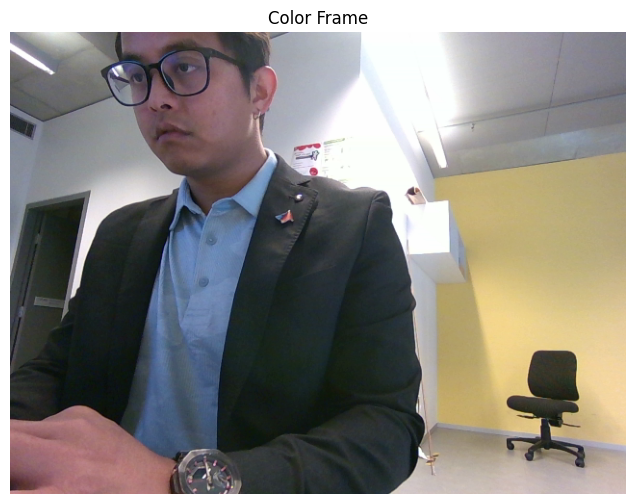

In [10]:
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
plt.title("Color Frame")
plt.axis('off')
plt.show()


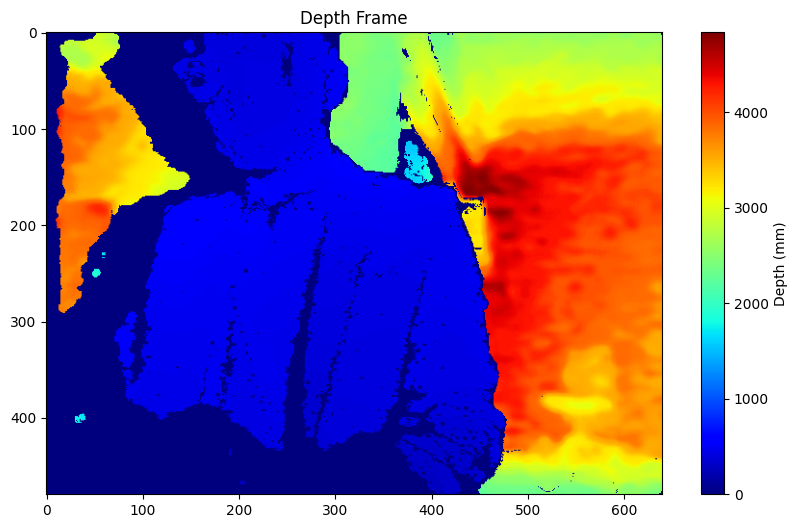

In [11]:
plt.figure(figsize=(10, 6))
plt.imshow(depth_image, cmap='jet')
plt.colorbar(label='Depth (mm)')
plt.title("Depth Frame")
plt.show()


Image center: (320, 240)
Depth at center: 0.434 meters
Depth at center: 434.0 mm


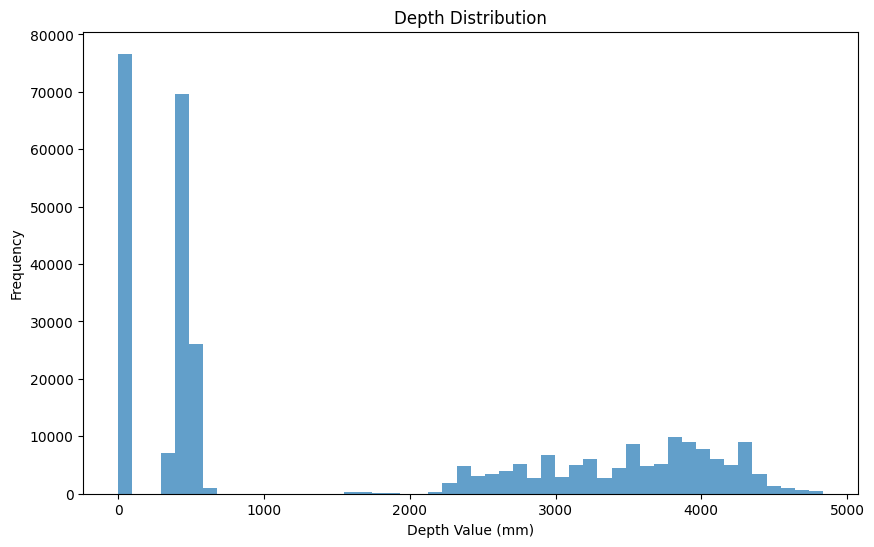

In [13]:
h, w = depth_image.shape
center_x, center_y = w//2, h//2
center_depth = depth_frame.get_distance(center_x, center_y)

print(f"Image center: ({center_x}, {center_y})")
print(f"Depth at center: {center_depth:.3f} meters")
print(f"Depth at center: {center_depth*1000:.1f} mm")

plt.figure(figsize=(10, 6))
plt.hist(depth_image.flatten(), bins=50, alpha=0.7)
plt.xlabel('Depth Value (mm)')
plt.ylabel('Frequency')
plt.title('Depth Distribution')
plt.show()



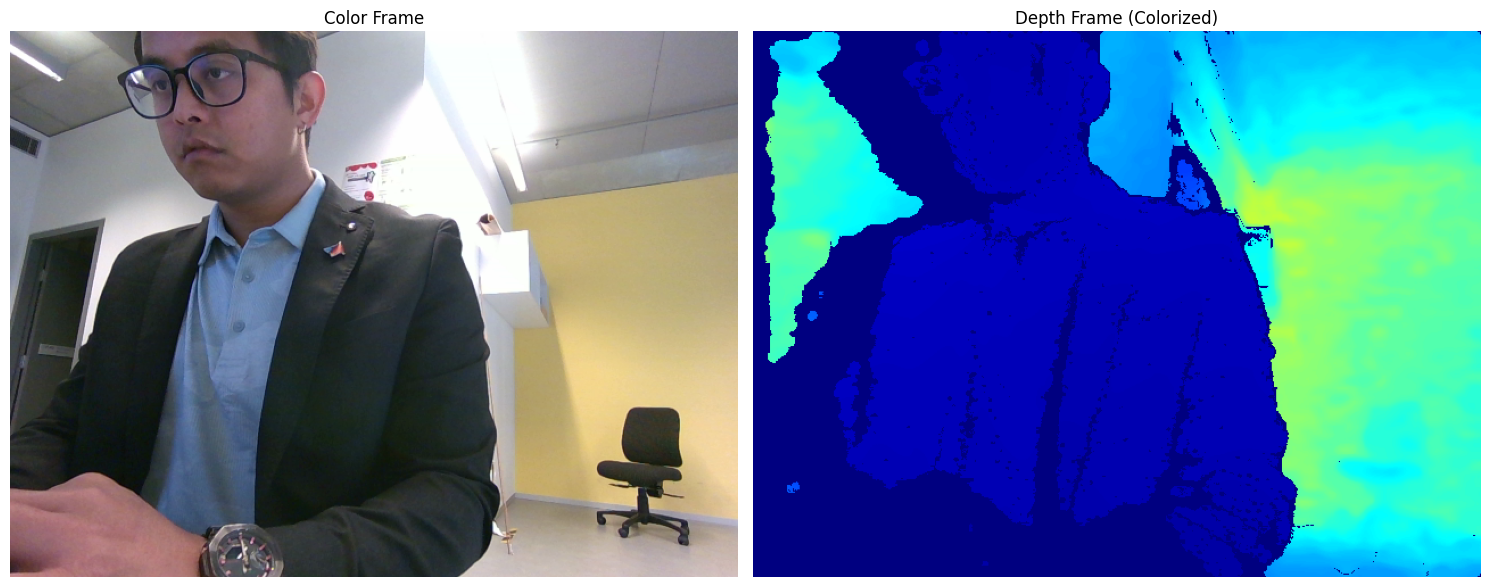

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
ax1.set_title('Color Frame')
ax1.axis('off')

depth_colormap = cv2.applyColorMap(cv2.convertScaleAbs(depth_image, alpha=0.03), cv2.COLORMAP_JET)
ax2.imshow(cv2.cvtColor(depth_colormap, cv2.COLOR_BGR2RGB))
ax2.set_title('Depth Frame (Colorized)')
ax2.axis('off')

plt.tight_layout()
plt.show()


In [15]:
pipeline.stop()
print("Pipeline stopped")


Pipeline stopped


# Live Preview

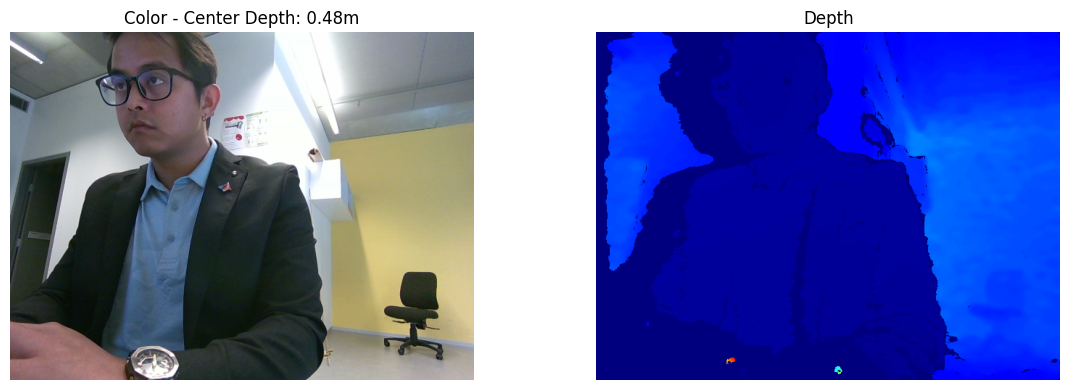

In [18]:
def live_preview(duration=10):
    pipeline = rs.pipeline()
    config = rs.config()
    config.enable_stream(rs.stream.depth, 640, 480, rs.format.z16, 30)
    config.enable_stream(rs.stream.color, 640, 480, rs.format.bgr8, 30)
    
    pipeline.start(config)
    
    start_time = time.time()
    try:
        while time.time() - start_time < duration:
            frames = pipeline.wait_for_frames()
            depth_frame = frames.get_depth_frame()
            color_frame = frames.get_color_frame()
            
            if not depth_frame or not color_frame:
                continue
                
            depth_image = np.asanyarray(depth_frame.get_data())
            color_image = np.asanyarray(color_frame.get_data())
            
            center_depth = depth_frame.get_distance(320, 240)
            
            clear_output(wait=True)
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
            
            ax1.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
            ax1.set_title(f'Color - Center Depth: {center_depth:.2f}m')
            ax1.axis('off')
            
            ax2.imshow(depth_image, cmap='jet')
            ax2.set_title('Depth')
            ax2.axis('off')
            
            plt.tight_layout()
            plt.show()
            time.sleep(0.1)
            
    finally:
        pipeline.stop()

# Uncomment to run live preview for 10 seconds
live_preview(10)


# compare depth with DepthAnything


In [20]:
import pyrealsense2 as rs
import cv2
import torch
import numpy as np
from transformers import pipeline
import matplotlib.pyplot as plt
from PIL import Image

# Initialize DepthAnything model
depth_estimator = pipeline(
    task="depth-estimation",
    model="depth-anything/Depth-Anything-V2-Small-hf",
    device=0 if torch.cuda.is_available() else -1
)
print("DepthAnything model loaded")


x:\ARIA_vision\Aria_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


DepthAnything model loaded


In [21]:
pipeline = rs.pipeline()
config = rs.config()
config.enable_stream(rs.stream.depth, 640, 480, rs.format.z16, 30)
config.enable_stream(rs.stream.color, 640, 480, rs.format.bgr8, 30)
pipeline.start(config)
print("RealSense pipeline started")


RealSense pipeline started


In [22]:
def process_with_depthanything(color_frame):
    # Convert BGR to RGB
    frame_rgb = cv2.cvtColor(color_frame, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(frame_rgb)
    
    # Get AI depth estimation
    depth_result = depth_estimator(pil_image)
    depth_map = np.array(depth_result['depth'])
    
    # Apply colormap and resize
    depth_colored = cv2.applyColorMap(depth_map, cv2.COLORMAP_JET)
    depth_colored = cv2.resize(depth_colored, (color_frame.shape[1], color_frame.shape[0]))
    
    return depth_colored

# Capture single frame
frames = pipeline.wait_for_frames()
color_frame = np.asanyarray(frames.get_color_frame().get_data())
depth_frame = np.asanyarray(frames.get_depth_frame().get_data())

# Process with DepthAnything
ai_depth = process_with_depthanything(color_frame)


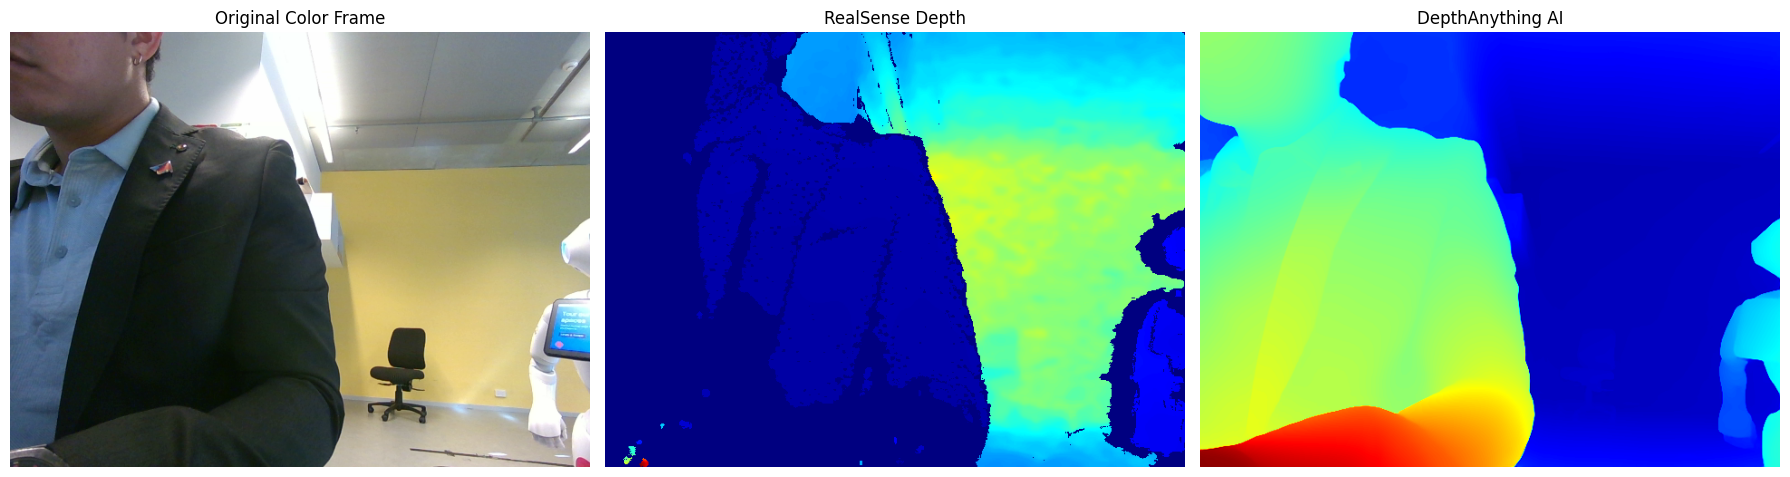

In [23]:
# Create RealSense depth visualization
rs_depth_colored = cv2.applyColorMap(cv2.convertScaleAbs(depth_frame, alpha=0.03), cv2.COLORMAP_JET)

# Display comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(color_frame, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Color Frame')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(rs_depth_colored, cv2.COLOR_BGR2RGB))
axes[1].set_title('RealSense Depth')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(ai_depth, cv2.COLOR_BGR2RGB))
axes[2].set_title('DepthAnything AI')
axes[2].axis('off')

plt.tight_layout()
plt.show()


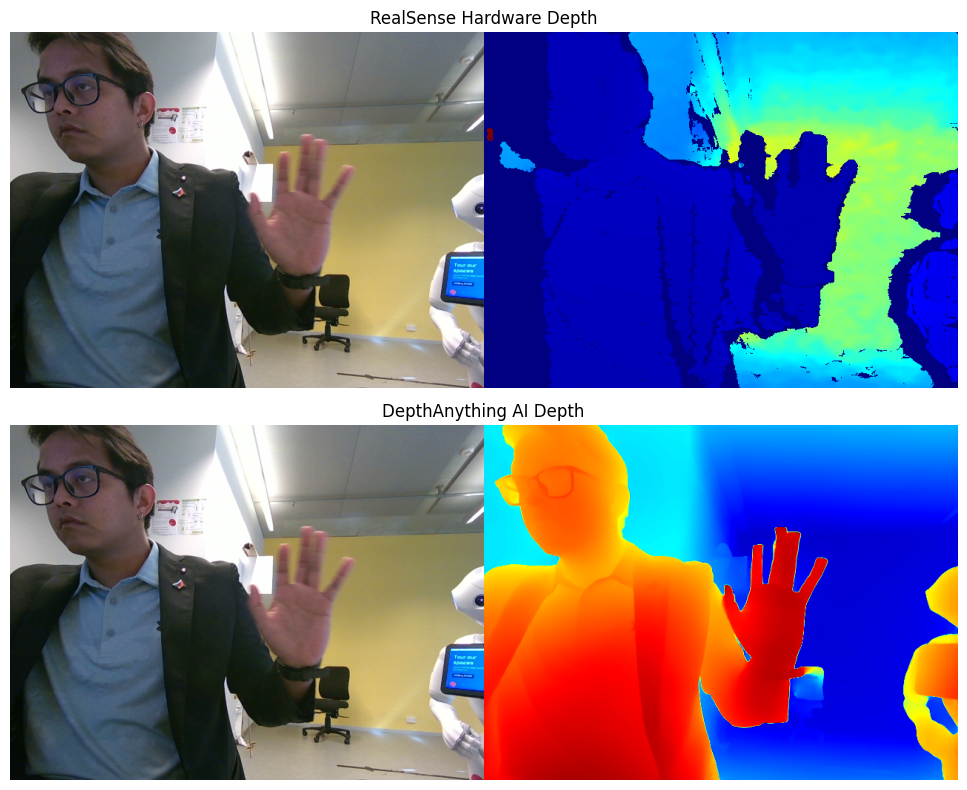

In [24]:
def live_comparison(duration=10):
    import time
    from IPython.display import clear_output
    
    start_time = time.time()
    while time.time() - start_time < duration:
        frames = pipeline.wait_for_frames()
        color_frame = np.asanyarray(frames.get_color_frame().get_data())
        depth_frame = np.asanyarray(frames.get_depth_frame().get_data())
        
        # Process frames
        ai_depth = process_with_depthanything(color_frame)
        rs_depth_colored = cv2.applyColorMap(cv2.convertScaleAbs(depth_frame, alpha=0.03), cv2.COLORMAP_JET)
        
        # Create combined views
        rs_combined = np.hstack((color_frame, rs_depth_colored))
        ai_combined = np.hstack((color_frame, ai_depth))
        
        clear_output(wait=True)
        fig, axes = plt.subplots(2, 1, figsize=(12, 8))
        
        axes[0].imshow(cv2.cvtColor(rs_combined, cv2.COLOR_BGR2RGB))
        axes[0].set_title('RealSense Hardware Depth')
        axes[0].axis('off')
        
        axes[1].imshow(cv2.cvtColor(ai_combined, cv2.COLOR_BGR2RGB))
        axes[1].set_title('DepthAnything AI Depth')
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
        time.sleep(0.5)

# Uncomment to run live comparison
live_comparison(10)


In [25]:
pipeline.stop()
print("Pipeline stopped")


Pipeline stopped
